## VeBNN training with one-dimensional illustrative example

In [1]:
# import packages
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from VeBNN.networks.mean_nets import MeanNet
from VeBNN.networks.variance_nets import GammaVarNet
from VeBNN.methods.sgmcmc_trainer import SGMCMCTrainer
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
# create the one-dimensional Xsin function with noise
def Xsin(x:torch.Tensor, train=False, noise_type: str= "homo") -> torch.Tensor:
    """ Xsin function with noise

    Parameters
    ----------
    x : torch.Tensor
        input tensor of the Xsin function
    train : bool, optional
        generating training or testing data, by default False
    noise_type : str, optional
        define the noise, by default "homo"

    Returns
    -------
    Responses
        responses of the input data points
    """
    if not train:
        return x * torch.sin(x)
    else:
        if noise_type == "heter":
            return x * torch.sin(x) + torch.abs(x) * torch.randn_like(x) * 0.3 + torch.randn_like(x) * 0.3
        elif noise_type == "homo":
            x * torch.sin(x) + torch.randn_like(x) * 0.5

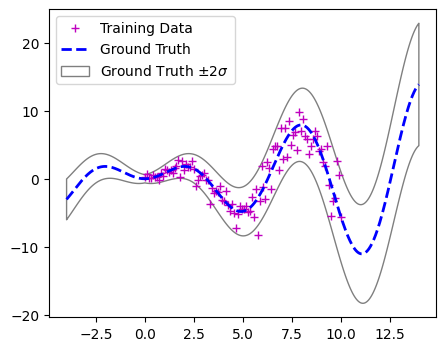

In [3]:
# generate data based on the defined function
samples = torch.linspace(0, 10, 100).reshape(-1, 1)
responses = Xsin(samples, train=True, noise_type="heter")
plot_samples = torch.linspace(-4, 14, 1400).reshape(-1, 1)
ground_truth = Xsin(plot_samples, train=False)


# plot the Xsin function
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(samples, responses, "m+", label="Training Data")
ax.plot(plot_samples, ground_truth,  "b--",
               linewidth=2, label="Ground Truth")
ax.fill_between(
        plot_samples.squeeze(),
        (ground_truth - 2*(torch.abs(plot_samples)*0.3 + 0.3)).squeeze(),
        (ground_truth + 2*(torch.abs(plot_samples)*0.3 + 0.3)).squeeze(),
        color="gray",
        edgecolor="black",
        facecolor="None",
        alpha=0.5,
        label=r"Ground Truth $\pm 2\sigma$",
    )
plt.legend()
plt.show()

In [4]:
# define the mean and variance networks
mean_mlp = nn.Sequential(
        nn.Linear(1, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, 1),
    )
mean_net = MeanNet(
    net=mean_mlp,
    prior_mu=0.0,
    prior_sigma=1.0,
)
variance_mlp = nn.Sequential(
    nn.Linear(1, 5),
    nn.Tanh(),
    nn.Linear(5, 2 * 1),
)
var_net = GammaVarNet(
    net=variance_mlp,
    prior_mu=0.0,
    prior_sigma=1.0,
)

In [5]:
# ====== build trainer ======
trainer = SGMCMCTrainer(
    mean_net=mean_net,
    var_net=var_net,
    device=torch.device("cuda"),
    job_id=1,  # any integer; used for temporary folder
)

# ====== configs (kept small so test is fast) ======
init_config = {
    "loss_name": "MSE",
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-6,
    "num_epochs": 2000,      # warm-up epochs
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "split_ratio": 0.8,
}

var_config = {
    "optimizer_name": "Adam",
    "lr": 1e-2,
    "num_epochs": 10000,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "early_stopping": False,
    "early_stopping_iter": 100,
    "early_stopping_tol": 1e-4,
}

sampler_config = {
    "sampler": "pSGLD",   # must match your VeBNN.samplers names
    "lr": 1e-3,
    "gamma": 0.9999,
    "num_epochs": 5000,    # SGMCMC epochs
    "mix_epochs": 100,     # thinning interval
    "burn_in_epochs": 1000,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 100,
}

# ====== run cooperative training ======
# iteration controls how many outer loops (var <-> mean) you do.
# For a quick test, iteration=2 is enough to see if everything works.
trainer.cooperative_train(
    x_train=samples,
    y_train=responses,
    iteration=2,
    init_config=init_config,
    var_config=var_config,
    sampler_config=sampler_config,
    delete_model_raw_data=True,  # delete temporary folder after training
)


Epoch 1/2000, Train loss: 1.602e+01, Val loss: 1.280e+01
Epoch 50/2000, Train loss: 1.358e+01, Val loss: 1.179e+01
Epoch 100/2000, Train loss: 1.148e+01, Val loss: 1.011e+01
Epoch 150/2000, Train loss: 1.045e+01, Val loss: 8.781e+00
Epoch 200/2000, Train loss: 9.588e+00, Val loss: 7.987e+00
Epoch 250/2000, Train loss: 8.817e+00, Val loss: 7.927e+00
Epoch 300/2000, Train loss: 8.154e+00, Val loss: 6.872e+00
Epoch 350/2000, Train loss: 7.578e+00, Val loss: 6.662e+00
Epoch 400/2000, Train loss: 7.162e+00, Val loss: 6.023e+00
Epoch 450/2000, Train loss: 6.821e+00, Val loss: 6.111e+00
Epoch 500/2000, Train loss: 6.466e+00, Val loss: 5.425e+00
Epoch 550/2000, Train loss: 6.042e+00, Val loss: 5.279e+00
Epoch 600/2000, Train loss: 5.413e+00, Val loss: 5.136e+00
Epoch 650/2000, Train loss: 4.790e+00, Val loss: 4.447e+00
Epoch 700/2000, Train loss: 4.136e+00, Val loss: 3.974e+00
Epoch 750/2000, Train loss: 3.868e+00, Val loss: 4.389e+00
Epoch 800/2000, Train loss: 3.664e+00, Val loss: 4.136e+00


C:\Users\JiaxiangYi\GitHub\VeBNN\src\VeBNN\methods\sgmcmc_trainer.py:191: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.mean_nets = torch.load(


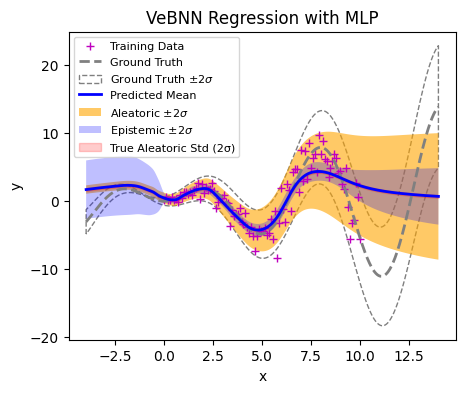

In [6]:
# get prediction for the plot_samples
pred_mean, pred_epistemic_var = trainer.bayes_predict(plot_samples)
pred_aleatoric_var = trainer.aleatoric_variance_predict(plot_samples)
# detach
pred_mean = pred_mean.cpu().detach()
pred_epistemic_var = pred_epistemic_var.cpu().detach()
pred_aleatoric_var = pred_aleatoric_var.cpu().detach()

fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(samples, responses, "m+",  label="Training Data")
ax.plot(plot_samples, ground_truth,  "--", color="gray",
               linewidth=2, label="Ground Truth")
# plot ground truth with 2 std
ax.fill_between(
    plot_samples.squeeze(),
    (ground_truth - 2*(0.3+0.3*plot_samples )).squeeze(),
    (ground_truth + 2*(0.3+0.3*plot_samples)).squeeze(),
    color="gray",
    edgecolor="black",
    facecolor="None",
    linestyle="--",
    alpha=0.5,
    label=r"Ground Truth $\pm 2\sigma$",
)
# plot the prediction
ax.plot(plot_samples, pred_mean, color="b",
            linewidth=2,  label="Predicted Mean")
# plot the Aleatoric uncertainty
ax.fill_between(
    plot_samples.squeeze(),
    (pred_mean - 2*pred_aleatoric_var**0.5).squeeze(),
    (pred_mean + 2*pred_aleatoric_var**0.5).squeeze(),
    color="orange",
    alpha=0.6,
    edgecolor="None",
    label=r"Aleatoric $\pm 2\sigma$",

)
# plot the Epistemic uncertainty
ax.fill_between(
    plot_samples.squeeze(),
    (pred_mean - 2*pred_epistemic_var**0.5).squeeze(),
    (pred_mean + 2*pred_epistemic_var**0.5).squeeze(),
    color="blue",
    alpha=0.25,
    edgecolor="None",
    label=r"Epistemic $\pm 2\sigma$",

)
# plot the ground truth of aleatoric noise
y_true_ale_var = 0.1**2 * torch.ones_like(plot_samples)
y_true_ale_std = torch.sqrt(y_true_ale_var)
ax.fill_between(
    plot_samples.cpu().squeeze(),
    (pred_mean - 2 * y_true_ale_std).cpu().squeeze(),
    (pred_mean + 2 * y_true_ale_std).cpu().squeeze(),
    color='red', alpha=0.2, label='True Aleatoric Std (2σ)'
)
plt.title('VeBNN Regression with MLP')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(frameon=True, fontsize=8)
# plt.grid()
plt.show()

